## Bayesian Learning and Decision-Making Under Uncertainty



#### 1. Introduction: 

Risky decisions are taken on an everyday basis. Examples include investment decisions, buying insurance, buying lottery tickets, what major to pursue in college, what career path to choose, and so on. Many of these cases involve learning from experience rather than description. This is because probabilities and outcomes are not explicitly known, but can be inferred from enough exploration. Understanding how people learning from sequential experience in a risky environment is important in making optimal choices in financial, business, medical, technological, and many other real-world contexts. 

A mathematical framework that studies decision making in experience scenarios is called the multi-armed bandit problem. In this setting the decision maker sequentially chooses one of multiple choices where the properties of each choice are only partially known at the time of the choice, and may become better understood through more trials (Wikipedia contributors, 2026).

In this project we will focus on choices between two alternatives- a safe one that yields a medium outcome with certainty and a risky one that yields different outcomes with different probabilities. The decision maker will  repeatedly choose between these two options and observe and receive the outcomes. He or she gradually learns about the expected payoffs of the options and can make more informative subsequent decisions to increase his or her total payoffs. We model this learning process and simulate different decision strategies to see how beliefs evolve over time and how they influence choice behavior.    

#### 2. Mathematical Model 

##### 2.1. Multi-Armed Bandit

The name 'multi-armed bandit' originates from slot machines in casinos, where each machine represents an “arm” that produces rewards with some probability distribution. A decision maker repeatedly chooses which arm to pull and receives rewards that depend on the selected arm. 

Formally, consider a set of $K$ available actions (or arms): $A = {1,2,...,K}$. Each arm $i$ is associated with an unknown reward distribution with expected value $\mu_i = E[R_i]$ where $R_i$ denotes the reward obtained when arm $i$ is chosen.

At each time period $t = 1,2,...,T$, the decision maker selects an arm $a_t \in A$.

The goal of the decision maker is to maximize the total payoffs: $\max \sum_{t=1}^{T} R_t$. The classical multi-armed bandit problem also incorporates a regret component in the model. For simplicity reasons, we will adhere to the model without this additional regret component. 


The decision maker has to find a strategy that balances between exploration and exploitation. On the one hand, exploring different arms provides information about their payoff distributions. On the other hand, exploiting the arm that currently appears to yield the highest payoff increases immediate payoffs.

##### 2.2. Two-Armed Case (our setting)

In this project we will focus on a special case of the multi-armed bandit problem, where there are only two options ($K=2$). The action set is then: $A = \{S, R\}$ where $S$ denotes the safe option and $R$ denotes the risky option. At each time period $t = 1,2,\dots,T$, the decision maker chooses an action $a_t \in \{S,R\}$ and observes a realized payoff $R_t$:


$$
R_t =
\begin{cases}
c, & \text{if } a_t = S,\\
X_t, & \text{if } a_t = R,
\end{cases}
$$

where $c > 0$ is a fixed payoff and $X_t$ is a stochastic payoff, taking on the following form: 

$$
X_t =
\begin{cases}
r, & \text{with probability } p,\\
0, & \text{with probability } 1-p.
\end{cases}
$$

where $r$ is a high outcome ($r > c$) and the probability $p$ is the probability to yield $r$. The decision maker does not know the payoff structure of either option in advance. In particular, the decision maker does not initially know that the safe option always yields the same payoff $c$. Instead, the properties of both options must be learned through repeated sampling and observation of realized outcomes.

##### 2.3. Learning from Experience

The decision maker does not know the payoff distributions of either option in advance. The outcomes associated with both the safe and the risky option must therefore be learned through repeated observations of realized rewards. In each period $t = 1,2,\dots,T$, the decision maker chooses an option and observes the resulting payoff.

Let $R_{i,t}$ denote the reward obtained when option $i \in \{S,R\}$ is selected at time $t$. The decision maker forms an estimate of the expected reward of each option based on previously observed outcomes.

Let $n_i(t)$ denote the number of times option $i$ has been chosen up to time $t$. The estimated expected reward of option $i$ is given by the sample mean of observed rewards:

$$
\hat{\mu}_i(t) =
\frac{1}{n_i(t)}
\sum_{k=1}^{n_i(t)} R_{i,k}.
$$

After each new observation, the estimate can be updated incrementally. If option $i$ is chosen at time $t$ and produces reward $R_{i,t}$, the updated estimate becomes

$$
\hat{\mu}_i(t+1) =
\hat{\mu}_i(t)
+
\frac{1}{n_i(t)}
\left(R_{i,t} - \hat{\mu}_i(t)\right).
$$

This updating rule allows the decision maker to revise beliefs about the expected payoff of each option as more information becomes available.

As the number of observations increases, the estimated expected rewards converge toward the true expected rewards of the options. These evolving estimates guide the decision maker's subsequent choices and determine how exploration and exploitation are balanced across periods.

##### 2.4. Decision Strategies

Once the decision maker forms estimates of the expected rewards of the two options, the next step is to determine how these estimates influence the choice of option. Different decision strategies balance exploration and exploitation in different ways. Exploration refers to sampling options in order to learn more about their payoffs and probability distributions. Exploitation refers to selecting the option that currently appears to yield the highest reward.

Let $\hat{\mu}_i(t)$ denote the estimated expected reward of option $i \in \{S,R\}$ at time $t$, based on previously observed outcomes. Below we will look at three popular strategies and how decisions are made under currently available information at time $t$. In the present framework, the decision maker does not explicitly model the probability of success of each option. Instead, the expected rewards of the options are estimated directly from observed outcomes, and the decision strategies are based on these estimated reward values.

2.4.1. Greedy Strategy

A simple strategy is the greedy strategy, which always selects the option with the highest estimated expected reward. The chosen action at time $t$ is:

$$
a_t = \arg\max_{i \in \{S,R\}} \hat{\mu}_i(t).
$$

Under this strategy, the decision maker exploits the option that currently appears to perform best. The main weakness of the greedy strategy is that it is sensitive to early observations and does not encourage exploration. As a result, if an option yields a favorable outcome early on, the decision maker may repeatedly choose that option without collecting additional information about the alternative option.

2.4.2. Upper Confidence Bound (UCB)

The Upper Confidence Bound (UCB) strategy introduces an explicit mechanism for balancing exploration and exploitation (Auer, 2002). In addition to the estimated expected reward, the decision maker considers the uncertainty associated with that estimate.

At time period $t$, the decision maker selects the option that maximizes

$$
a_t = \arg\max_{i \in \{S,R\}}
\left(
\hat{\mu}_i(t) +
\sqrt{\frac{2 \ln t}{n_i(t)}}
\right),
$$

where $n_i(t)$ denotes the number of times option $i$ has been selected up to time $t$.

The first term represents the estimated expected reward of the option, while the second term is an exploration term. As the number of observations increases, the exploration term decreases, and the strategy gradually favors the option with the higher estimated payoff.

2.4.3. Thompson Sampling

Thompson Sampling is a probabilistic strategy that balances exploration and exploitation by selecting actions according to their probability of being optimal (Thompson, 1933). Instead of choosing the option with the highest current estimate, the decision maker samples a plausible value of the expected reward for each option.

Let $\tilde{\mu}_i(t)$ denote a sampled value representing a plausible expected reward of option $i$. A simple approximation is to draw this value from a normal distribution centered at the estimated reward:

$$
\tilde{\mu}_i(t) \sim \mathcal{N}\!\left(\hat{\mu}_i(t),\; \frac{\sigma_0^2}{n_i(t)}\right),
$$

where $\sigma_0^2$ represents the initial uncertainty about the expected reward of the option.

At each time period $t$, the decision maker chooses the option with the highest sampled value:

$$
a_t = \arg\max_{i \in \{S,R\}} \tilde{\mu}_i(t).
$$

Options that have been sampled fewer times have greater uncertainty and more dispersed sampling distributions. They could generate a high sampled value with a greter probability, which encourages exploration but also favors the option with the higher estimated payoff.

#### 3. Python Implementation

##### 3.1. Environmental Setup

To study how different decision strategies perform in this binary choice environment, we conduct a series of simulations in Python. The decision maker repeatedly chooses between a safe option and a risky option over a finite time horizon $T$. The safe option yields a constant payoff $c$, while the risky option yields a payoff $r$ with probability $p$ and zero otherwise. The decision maker does not know initially the payoffs of the options and the probabilities with which they occur. Instead, the probaibilities and outcomes of the options must be learned through repeated sampling and observation of realized outcomes.

Let $\hat{\mu}_i(t)$ denote the estimated expected reward of option $i \in \{S,R\}$ at time $t$. At each time period the decision maker selects an option according to a particular decision strategy. After each choice the realized payoff of option $i$ is incorporated into the estimate of the corresponding option's expected reward.

The performance of the different decision strategies is evaluated by comparing the cumulative payoffs obtained over time. We vary the probability of the risky option, the expected values of the options, and the time horizon for a detailed analysis of how the performance varies when key features of the environment also vary.

##### 3.2. Python Code

In [1]:
# Import libraries for numerical computation and plotting

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Environmental Parameters

T = 1000         # number of time periods
c = 3            # payoff of the safe option
r = 4            # payoff of the high outcome of the risky option
p = 0.8          # probability of getting the high outcome of the risky option

In [12]:
# Thompson Strategy

# Lists of choices made and rewards received

choices_ts = []
rewards_ts = []

# Counts of option choices and mean rewards (initial mean rewards set to 0)

n_S, n_R = 0, 0
Q_S, Q_R = 0.0, 0.0

sigma0 = 10.0  # Initial variance parameter (greater coefficient encourages more exploration)  

for t in range(T):

    #
    if n_S == 0:
        choice = "S"
    elif n_R == 0:
        choice = "R"
    else:
        # Sample a plausible mean reward for each option
        sample_S = np.random.normal(Q_S, sigma0 / np.sqrt(n_S))
        sample_R = np.random.normal(Q_R, sigma0 / np.sqrt(n_R))

        choice = "R" if sample_R > sample_S else "S"

    choices_ts.append(choice)

    # Reward Outcomes
    if choice == "S":
        reward = c
        n_S += 1
        Q_S += (reward - Q_S) / n_S
    else:
        success = np.random.rand() < p
        reward = r * success
        n_R += 1
        Q_R += (reward - Q_R) / n_R

    rewards_ts.append(reward)

cumulative_rewards_thompson = np.cumsum(rewards_ts)

print("Thompson Strategy")
print("Safe chosen:", choices_ts.count("S"))
print("Risky chosen:", choices_ts.count("R"))

Thompson Strategy
Safe chosen: 405
Risky chosen: 595


In [13]:
# Greedy strategy

# Lists of choices made and rewards received

choices_greedy = []
rewards_greedy = []

# Counts of option choices and mean rewards (initial mean rewards set to 0)

n_S, n_R = 0, 0
Q_S, Q_R = 0.0, 0.0

for t in range(T):

    # Force each option to be chosen at least once (to ensure that we divide by a non-zero number when calculating estimated mean rewards)
    if n_S == 0 and n_R == 0:
        choice = "R" if np.random.rand() < 0.5 else "S"
    elif n_S == 0:
        choice = "S"
    elif n_R == 0:
        choice = "R"
    else:
        if Q_R > Q_S:
            choice = "R"
        elif Q_S > Q_R:
            choice = "S"
        else:
            choice = "R" if np.random.rand() < 0.5 else "S"

    choices_greedy.append(choice)

    # Reward Outcomes
    if choice == "S":
        reward = c
        n_S += 1
        Q_S += (reward - Q_S) / n_S  
    else:
        success = np.random.rand() < p
        reward = r * success
        n_R += 1
        Q_R += (reward - Q_R) / n_R

    rewards_greedy.append(reward)

cumulative_rewards_greedy = np.cumsum(rewards_greedy)

print("Greedy Strategy")
print("Safe chosen:", choices_greedy.count("S"))
print("Risky chosen:", choices_greedy.count("R"))

Greedy Strategy
Safe chosen: 935
Risky chosen: 65


In [14]:
# UCB strategy 

# Lists of choices made and rewards received

choices_ucb = []
rewards_ucb = []

# Counts of option choices and mean rewards (initial mean rewards set to 0)

n_S, n_R = 0, 0
Q_S, Q_R = 0.0, 0.0


for t in range(1, T + 1):

    # Force each option to be chosen at least once (to ensure that we divide by a non-zero number when calculating estimated mean rewards)
    if n_S == 0:
        choice = "S"
    elif n_R == 0:
        choice = "R"
    else:
        ucb_S = Q_S + np.sqrt(2 * np.log(t) / n_S)
        ucb_R = Q_R + np.sqrt(2 * np.log(t) / n_R)
        
        if ucb_R > ucb_S:
            choice = "R"
        elif ucb_S > ucb_R:
            choice = "S"
        else:
            choice = "R" if np.random.rand() < 0.5 else "S"

    choices_ucb.append(choice)

    # Reward Outcomes
    if choice == "S":
        reward = c
        n_S += 1
        Q_S += (reward - Q_S) / n_S
    else:
        success = np.random.rand() < p
        reward = r * success
        n_R += 1
        Q_R += (reward - Q_R) / n_R

    rewards_ucb.append(reward)

cumulative_rewards_ucb = np.cumsum(rewards_ucb)

print("UCB Strategy")
print("Safe chosen:", choices_ucb.count("S"))
print("Risky chosen:", choices_ucb.count("R"))

UCB Strategy
Safe chosen: 103
Risky chosen: 897


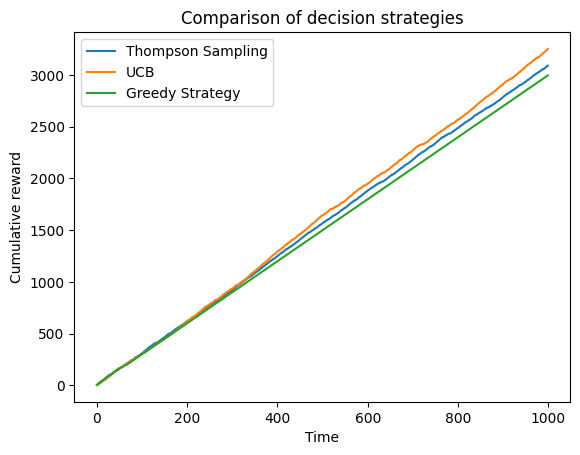

In [15]:
plt.plot(cumulative_rewards_thompson, label="Thompson Sampling")
plt.plot(cumulative_rewards_ucb, label="UCB")
plt.plot(cumulative_rewards_greedy, label="Greedy Strategy")

plt.xlabel("Time")
plt.ylabel("Cumulative reward")
plt.title("Comparison of decision strategies")
plt.legend()
plt.show()

In [18]:
print("UCB:  S =", choices_ucb.count("S"), " R =", choices_ucb.count("R"))
print("Greedy:  S =", choices_greedy.count("S"), " R =", choices_greedy.count("R"))
print("Thompson:S =", choices_ts.count("S"), " R =", choices_ts.count("R"))

UCB:  S = 103  R = 897
Greedy:  S = 935  R = 65
Thompson:S = 405  R = 595


#### Monte Carlo Simulation 

The above simulations purely illustrate how the three decision strategies operate over time in a sequential choice environment. In order to have more general and stronger claims on which strategy performs better or which strategy generates more risky or safe choices on average, we need to adhere to a Monte Carlo analysis. Monte Carlo is a computational algorithm that uses repeated random sampling to obtain the likelihood of possible outcomes of an unknown event. Below is the Monte Carlo simulation code.   

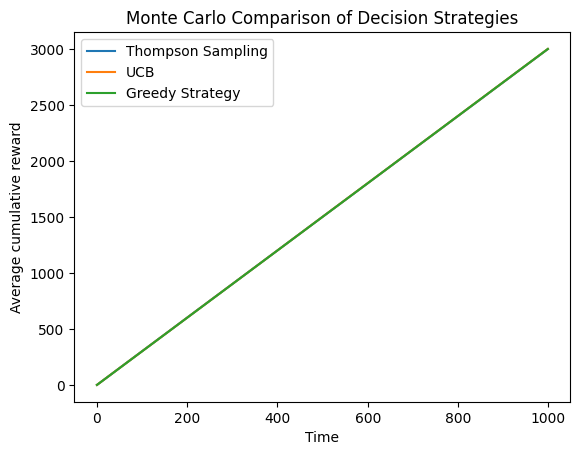

Average number of choices over 1000 Monte Carlo runs:
Thompson Sampling - Safe: 509.631 Risky: 490.369
UCB - Safe: 835.951 Risky: 164.049
Greedy Strategy - Safe: 961.387 Risky: 38.613


In [23]:
# Import libraries for numerical computation and plotting

import numpy as np
import matplotlib.pyplot as plt

# Environmental parameters
T = 1000         # number of time periods
c = 3            # payoff of the safe option
r = 6            # payoff of the high outcome of the risky option
p = 0.5          # probability of getting the high outcome of the risky option

# Number of Monte Carlo repetitions
n_runs = 1000

# Arrays to store average cumulative rewards
avg_cumulative_rewards_thompson = np.zeros(T)
avg_cumulative_rewards_greedy = np.zeros(T)
avg_cumulative_rewards_ucb = np.zeros(T)

# Lists to store numbers of safe and risky choices
safe_choices_thompson = []
risky_choices_thompson = []

safe_choices_greedy = []
risky_choices_greedy = []

safe_choices_ucb = []
risky_choices_ucb = []

for run in range(n_runs):

    # ----------------------------
    # Thompson Strategy
    # ----------------------------
    choices_ts = []
    rewards_ts = []

    n_S, n_R = 0, 0
    Q_S, Q_R = 0.0, 0.0

    sigma0 = 10.0

    for t in range(T):

        if n_S == 0:
            choice = "S"
        elif n_R == 0:
            choice = "R"
        else:
            sample_S = np.random.normal(Q_S, sigma0 / np.sqrt(n_S))
            sample_R = np.random.normal(Q_R, sigma0 / np.sqrt(n_R))

            choice = "R" if sample_R > sample_S else "S"

        choices_ts.append(choice)

        if choice == "S":
            reward = c
            n_S += 1
            Q_S += (reward - Q_S) / n_S
        else:
            success = np.random.rand() < p
            reward = r * success
            n_R += 1
            Q_R += (reward - Q_R) / n_R

        rewards_ts.append(reward)

    cumulative_rewards_thompson = np.cumsum(rewards_ts)
    avg_cumulative_rewards_thompson += cumulative_rewards_thompson

    safe_choices_thompson.append(choices_ts.count("S"))
    risky_choices_thompson.append(choices_ts.count("R"))

    # ----------------------------
    # Greedy Strategy
    # ----------------------------
    choices_greedy = []
    rewards_greedy = []

    n_S, n_R = 0, 0
    Q_S, Q_R = 0.0, 0.0

    for t in range(T):

        if n_S == 0 and n_R == 0:
            choice = "R" if np.random.rand() < 0.5 else "S"
        elif n_S == 0:
            choice = "S"
        elif n_R == 0:
            choice = "R"
        else:
            if Q_R > Q_S:
                choice = "R"
            elif Q_S > Q_R:
                choice = "S"
            else:
                choice = "R" if np.random.rand() < 0.5 else "S"

        choices_greedy.append(choice)

        if choice == "S":
            reward = c
            n_S += 1
            Q_S += (reward - Q_S) / n_S
        else:
            success = np.random.rand() < p
            reward = r * success
            n_R += 1
            Q_R += (reward - Q_R) / n_R

        rewards_greedy.append(reward)

    cumulative_rewards_greedy = np.cumsum(rewards_greedy)
    avg_cumulative_rewards_greedy += cumulative_rewards_greedy

    safe_choices_greedy.append(choices_greedy.count("S"))
    risky_choices_greedy.append(choices_greedy.count("R"))

    # ----------------------------
    # UCB Strategy
    # ----------------------------
    choices_ucb = []
    rewards_ucb = []

    n_S, n_R = 0, 0
    Q_S, Q_R = 0.0, 0.0

    for t in range(1, T + 1):

        if n_S == 0:
            choice = "S"
        elif n_R == 0:
            choice = "R"
        else:
            ucb_S = Q_S + np.sqrt(2 * np.log(t) / n_S)
            ucb_R = Q_R + np.sqrt(2 * np.log(t) / n_R)

            if ucb_R > ucb_S:
                choice = "R"
            elif ucb_S > ucb_R:
                choice = "S"
            else:
                choice = "R" if np.random.rand() < 0.5 else "S"

        choices_ucb.append(choice)

        if choice == "S":
            reward = c
            n_S += 1
            Q_S += (reward - Q_S) / n_S
        else:
            success = np.random.rand() < p
            reward = r * success
            n_R += 1
            Q_R += (reward - Q_R) / n_R

        rewards_ucb.append(reward)

    cumulative_rewards_ucb = np.cumsum(rewards_ucb)
    avg_cumulative_rewards_ucb += cumulative_rewards_ucb

    safe_choices_ucb.append(choices_ucb.count("S"))
    risky_choices_ucb.append(choices_ucb.count("R"))

# Compute average cumulative rewards
avg_cumulative_rewards_thompson /= n_runs
avg_cumulative_rewards_greedy /= n_runs
avg_cumulative_rewards_ucb /= n_runs

# Plot average cumulative rewards
plt.plot(avg_cumulative_rewards_thompson, label="Thompson Sampling")
plt.plot(avg_cumulative_rewards_ucb, label="UCB")
plt.plot(avg_cumulative_rewards_greedy, label="Greedy Strategy")

plt.xlabel("Time")
plt.ylabel("Average cumulative reward")
plt.title("Monte Carlo Comparison of Decision Strategies")
plt.legend()
plt.show()

# Print average numbers of choices
print("Average number of choices over", n_runs, "Monte Carlo runs:")
print("Thompson Sampling - Safe:", np.mean(safe_choices_thompson), "Risky:", np.mean(risky_choices_thompson))
print("UCB - Safe:", np.mean(safe_choices_ucb), "Risky:", np.mean(risky_choices_ucb))
print("Greedy Strategy - Safe:", np.mean(safe_choices_greedy), "Risky:", np.mean(risky_choices_greedy))

#### Results and Discussion

## Bibliography: 

Wikipedia contributors. (2026). Multi-armed bandit. Wikipedia.
https://en.wikipedia.org/wiki/Multi-armed_bandit

Auer, P., Cesa-Bianchi, N., & Fischer, P. (2002).
Finite-time analysis of the multiarmed bandit problem.
Machine Learning, 47(2–3), 235–256.

Sutton Bartol book 2014-15

Thompson, W. R. (1933).
On the likelihood that one unknown probability exceeds another in view of the evidence of two samples.
Biometrika, 25(3–4), 285–294.

https://www.ibm.com/think/topics/monte-carlo-simulation